# Week 06 — EDA Precision Lab

## Complete EDA Precision Report

This notebook is a submission-quality EDA report built from the exact `students` dataset specified in the lab.

It covers:
- dataset diagnosis
- genuine and null relationships
- categorical comparison
- line-chart trap
- visual QA and layout correction
- deliberate color and category order
- correlation vs. causation
- Pearson vs. Spearman
- bootstrap confidence interval
- small multiples
- self-audit
- pre-submission checklist
- technical summary and limitation

**Reproducibility:** The notebook uses a fixed random seed and all reported numerical findings are generated from variables in code rather than manually entered values.

## 1. Dataset Generation

The dataset below is generated **exactly according to the task specification**.

### Import libraries
First, we import the libraries and generate the student dataset used throughout the lab. The fixed random seed keeps the generated data reproducible, while the variables represent study hours, sleep hours, attendance, class section, and exam score. This gives us a controlled dataset on which we can practice precise EDA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from IPython.display import Image, display

FIGURES = Path("Figures")
FIGURES.mkdir(exist_ok=True)

rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

print(f"Dataset rows: {students.shape[0]}")
print(f"Dataset columns: {students.shape[1]}")

Dataset rows: 600
Dataset columns: 6


### Finding
The dataset contains **600 students and 6 columns**. This confirms the expected dataset size and gives us six variables for the EDA analysis.

### Dataset Diagnosis

The standard diagnosis checks the dataset shape, data types, missing values, duplicates, and descriptive statistics. Even though this dataset is clean by construction, I still perform these checks because they help build the habit of diagnosing the data before analysis

### What we are doing and why
Now we perform the basic dataset diagnosis. We check the shape, column information, missing values, duplicate rows, and descriptive statistics so we know the dataset is structurally valid before drawing conclusions from it.

In [2]:
print("Shape:")
print(students.shape)

print("\nInformation:")
students.info()

print("\nMissing values:")
print(students.isnull().sum())

print("\nDuplicate rows:")
print(students.duplicated().sum())

print("\nDescriptive statistics:")
display(students.describe())

Shape:
(600, 6)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    object 
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 28.2+ KB

Missing values:
student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

Duplicate rows:
0

Descriptive statistics:


,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000


### Finding
The diagnosis confirms 600 rows, 6 columns, no missing values, no duplicate rows, and the expected numeric/categorical data types.

## 2. Genuine Relationship — Study Hours vs. Exam Score

A scatter plot is appropriate because both variables are continuous numerical variables. Pearson correlation is computed to quantify the strength and direction of their linear association.

### Calculate the Pearson correlation
We calculate the Pearson correlation between weekly study hours and exam score. Pearson is appropriate here because both variables are numeric and we want to measure the strength and direction of their linear association.

In [3]:
r_study = students["study_hours_per_week"].corr(students["exam_score"])

print(f"Pearson correlation (study hours vs exam score): {r_study:.4f}")

Pearson correlation (study hours vs exam score): 0.6895


### Finding
Pearson correlation is **0.6895**, showing a moderate positive linear association between study hours and exam score.

### Visualize the study-hours relationship
Now we visualize the study-hours relationship with a scatter plot and a fitted trend line. The scatter plot lets us inspect the actual observations, while the trend line makes the overall direction easier to see.

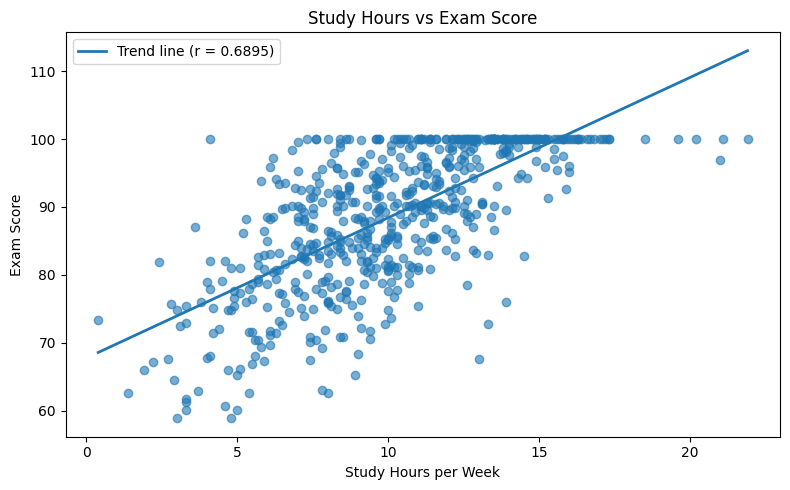

Saved figure: Figures/study_hours_vs_exam_score.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

x = students["study_hours_per_week"]
y = students["exam_score"]

ax.scatter(x, y, alpha=0.6)

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()
study_path = FIGURES / "study_hours_vs_exam_score.png"
fig.savefig(study_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {study_path}")

In [5]:
study_finding = (
    f"Students who reported more study hours per week tended to have higher "
    f"exam scores, with a Pearson correlation of r = {r_study:.4f}. "
    f"This is a positive association, not evidence that studying more directly "
    f"causes higher exam scores."
)
print(study_finding)

Students who reported more study hours per week tended to have higher exam scores, with a Pearson correlation of r = 0.6895. This is a positive association, not evidence that studying more directly causes higher exam scores.


### Finding
The reusable finding reports **r = 0.6895** directly from the computed variable, avoiding a manually typed numerical claim.

### Finding
Study hours and exam score show a **moderate positive relationship (r = 0.6895)**. This is an association in the generated dataset and does not establish causation.

## 3. Null Relationship — Sleep Hours vs. Exam Score

A null relationship is still a real finding. The scatter plot and Pearson correlation are used to determine whether sleep hours show a meaningful linear association with exam score.

### calculate Pearson correlation for sleep hours and exam score.
Next we calculate Pearson correlation for sleep hours and exam score. This is a useful null-relationship check: we should report a weak or near-zero result honestly if the data does not show a meaningful linear association.

In [6]:
r_sleep = students["sleep_hours_per_night"].corr(students["exam_score"])

print(f"Pearson correlation (sleep hours vs exam score): {r_sleep:.4f}")

Pearson correlation (sleep hours vs exam score): -0.0217


### Finding
Pearson correlation is **-0.0217**, indicating a negligible linear association between sleep hours and exam score.

### Scatter Plot
We create the scatter plot for sleep hours versus exam score and add a fitted trend line. The purpose is to visually check whether the near-zero correlation is consistent with the observed data.

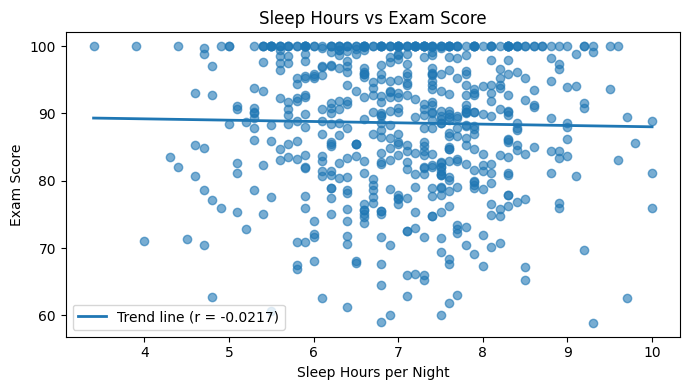

Saved figure: Figures/sleep_hours_vs_exam_score.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

x = students["sleep_hours_per_night"]
y = students["exam_score"]

ax.scatter(x, y, alpha=0.6)

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_sleep:.4f})"
)

ax.set_title("Sleep Hours vs Exam Score")
ax.set_xlabel("Sleep Hours per Night")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()
sleep_path = FIGURES / "sleep_hours_vs_exam_score.png"
fig.savefig(sleep_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {sleep_path}")

### Finding
The scatter plot shows no clear linear pattern, which is consistent with the near-zero Pearson correlation.

### Winterpetaton
We turn the sleep-hours correlation into a reproducible written finding. The f-string ensures that the reported correlation comes from the variable calculated above.

In [8]:
sleep_finding = (
    f"Sleep hours per night show no meaningful linear relationship with exam "
    f"score in this dataset, with a Pearson correlation of r = {r_sleep:.4f}. "
    f"The near-zero correlation indicates that variation in sleep hours is not "
    f"linearly associated with variation in exam scores in this dataset."
)
print(sleep_finding)

Sleep hours per night show no meaningful linear relationship with exam score in this dataset, with a Pearson correlation of r = -0.0217. The near-zero correlation indicates that variation in sleep hours is not linearly associated with variation in exam scores in this dataset.


### Finding
Sleep hours show a **negligible linear association** with exam score (r = -0.0217). Changes in reported sleep hours are not linearly associated with exam scores in this dataset.

## 4. Genuine Comparison — Exam Score by Class Section

Class section is categorical and exam score is continuous, so this is a comparison rather than a relationship.

**Shuffle test:** if the category labels are reordered, the group means remain the same; therefore the comparison remains the same. This is why a bar chart is appropriate, while a connected line would imply a trend between categories.

### calculate the average exam score for each class section
We calculate the average exam score for each class section and explicitly keep the natural A → B → C order. This is a categorical comparison, so we compare group means rather than treating the sections as a continuous variable.

In [9]:
section_means = students.groupby("class_section")["exam_score"].mean().reindex(["A", "B", "C"])
print(section_means)

mean_a = section_means.loc["A"]
mean_b = section_means.loc["B"]
mean_c = section_means.loc["C"]

print(
    f"Section A mean: {mean_a:.4f}\n"
    f"Section B mean: {mean_b:.4f}\n"
    f"Section C mean: {mean_c:.4f}"
)

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64
Section A mean: 87.6085
Section B mean: 87.0258
Section C mean: 91.3626


### Finding
Section C has the highest mean exam score (**91.36**), followed by Section A (**87.61**) and Section B (**87.03**).

### create the bar chart for the section means
We create the bar chart for the section means. A bar chart is appropriate because the class sections are separate categories and the goal is to compare their average exam scores.

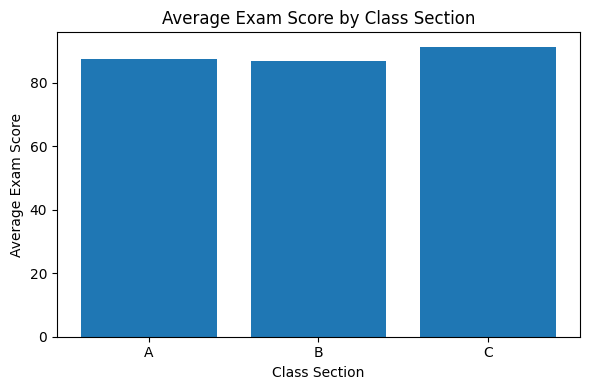

Saved figure: Figures/exam_score_by_class_section.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(section_means.index, section_means.values)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
comparison_path = FIGURES / "exam_score_by_class_section.png"
fig.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {comparison_path}")

### Finding
The bar chart provides a direct categorical comparison of the three section means while preserving A → B → C order.

### calculate the numerical differences
We calculate the numerical differences between the section means and build a finding from those values. This makes the comparison precise instead of relying only on visual height differences in the chart.

In [11]:
comparison_finding = (
    f"Section {section_means.idxmax()} has the highest average exam score "
    f"({section_means.max():.4f}), while Section {section_means.idxmin()} has "
    f"the lowest ({section_means.min():.4f}). The comparison is categorical "
    f"because changing the order of the section labels does not change the "
    f"underlying group means."
)
print(comparison_finding)

Section C has the highest average exam score (91.3626), while Section B has the lowest (87.0258). The comparison is categorical because changing the order of the section labels does not change the underlying group means.


### Finding
Sections A and B differ by only **0.58** points, while C is **3.75** points above A and **4.34** points above B.

Pearson (**0.6895**) and Spearman (**0.7010**) are close, with an absolute difference of **0.0115**. The positive relationship is therefore broadly consistent under both linear and rank-based measures.

## 5. Line-Chart Trap

A connected line chart is deliberately used on the section means to demonstrate the misleading implication created when unordered categories are treated as if they form a continuous sequence.

### Intentionally use a line chart for the section means.
We intentionally use a line chart for the section means. This is a deliberate trap: class sections are unordered categories, so connecting them with a line can imply a continuous trend that does not actually exist.

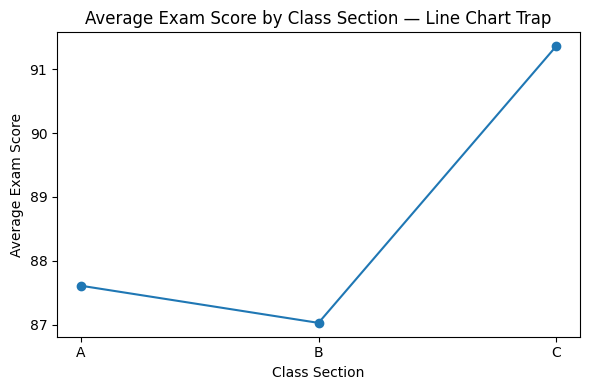

Saved figure: Figures/class_section_line_chart_trap.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    section_means.index,
    section_means.values,
    marker="o"
)

ax.set_title("Average Exam Score by Class Section — Line Chart Trap")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
trap_path = FIGURES / "class_section_line_chart_trap.png"
fig.savefig(trap_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {trap_path}")

### Finding
The line chart connects categorical means and therefore creates an implied progression between sections that is not supported by the variable type.

### What we are doing and why
We change the category order from A → B → C to C → A → B without changing any underlying scores. This is a shuffle test to demonstrate that the visual pattern of a categorical line chart can change simply because the display order changes.

In [13]:
shuffled_means = section_means.reindex(["C", "A", "B"])

print("Original order:")
print(section_means)

print("\nShuffled order:")
print(shuffled_means)

Original order:
class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

Shuffled order:
class_section
C    91.362632
A    87.608491
B    87.025758
Name: exam_score, dtype: float64


### Finding
The underlying means remain unchanged after reordering; only the order used to draw the line changes.

Section C has the highest mean exam score (**91.36**), followed by Section A (**87.61**) and Section B (**87.03**).

### Plot original and shuffled category orders side by side
We place the original and shuffled category orders side by side. Comparing the two versions makes the misleading effect of connecting unordered categories directly visible.

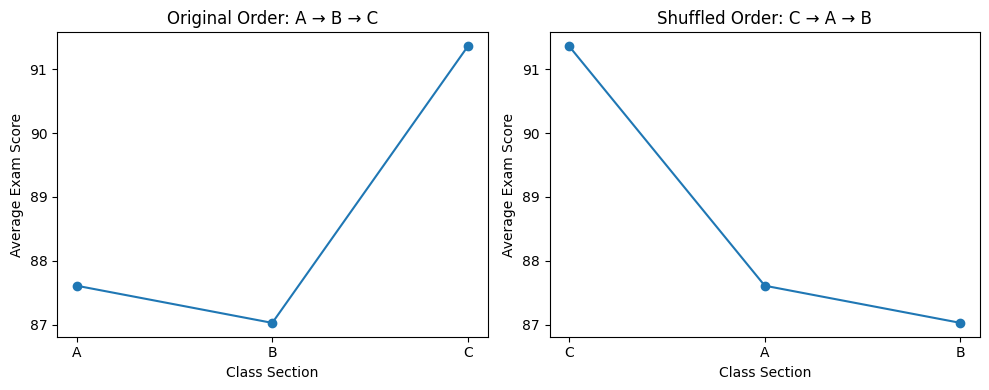

Saved figure: Figures/class_section_line_chart_trap_comparison.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(section_means.index, section_means.values, marker="o")
axes[0].set_title("Original Order: A → B → C")
axes[0].set_xlabel("Class Section")
axes[0].set_ylabel("Average Exam Score")

axes[1].plot(shuffled_means.index, shuffled_means.values, marker="o")
axes[1].set_title("Shuffled Order: C → A → B")
axes[1].set_xlabel("Class Section")
axes[1].set_ylabel("Average Exam Score")

fig.tight_layout()
trap_compare_path = FIGURES / "class_section_line_chart_trap_comparison.png"
fig.savefig(trap_compare_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {trap_compare_path}")

### Finding
The side-by-side comparison shows that changing category order changes the apparent line pattern, demonstrating why a line chart is misleading for unordered sections.

### Interpretation
We now move to visual quality assurance. The goal is to deliberately create a layout problem in a saved figure, inspect the actual PNG, then fix the problem and verify the corrected file.

In [15]:
trap_finding = (
    "The line chart creates a false impression of a continuous trend or path "
    "between class sections. Reordering the same categories changes the visual "
    "shape of the line even though the underlying means are unchanged, so a "
    "bar chart is more honest for this categorical comparison."
)
print(trap_finding)

The line chart creates a false impression of a continuous trend or path between class sections. Reordering the same categories changes the visual shape of the line even though the underlying means are unchanged, so a bar chart is more honest for this categorical comparison.


## 6. Visual QA — Deliberately Break and Then Fix the Layout

The saved PNG is the actual deliverable, so visual QA is performed on the saved file rather than relying only on the notebook preview.

First, the annotation is deliberately positioned in the same upper-right region as the legend to create a layout collision. The broken and fixed versions are both saved.

### Creating overlapping annotation on the scatter plot
We intentionally create a potentially overlapping annotation on the scatter plot. This is done on purpose so we can test the saved figure rather than assuming the notebook preview is sufficient.

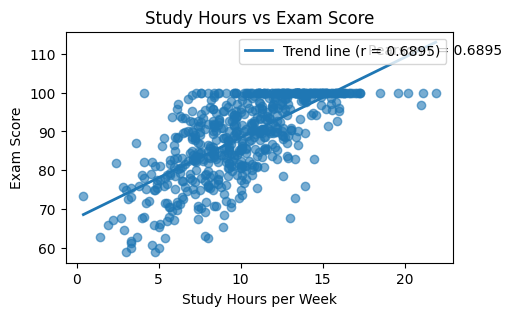

Saved broken version: Figures/study_hours_layout_broken.png


In [16]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend(loc="upper right")

# Deliberately collide with the legend.
ax.text(
    0.78,
    0.90,
    f"Pearson r = {r_study:.4f}",
    transform=ax.transAxes,
    fontsize=10
)

broken_path = FIGURES / "study_hours_layout_broken.png"
fig.savefig(broken_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved broken version: {broken_path}")

### Finding
The broken version intentionally introduces a layout collision so the saved PNG can be visually inspected and corrected.

### Saved-File QA Check — Broken Version

The saved PNG is opened directly below. The annotation was intentionally placed over the legend area, so this version demonstrates the collision that must be fixed before submission.

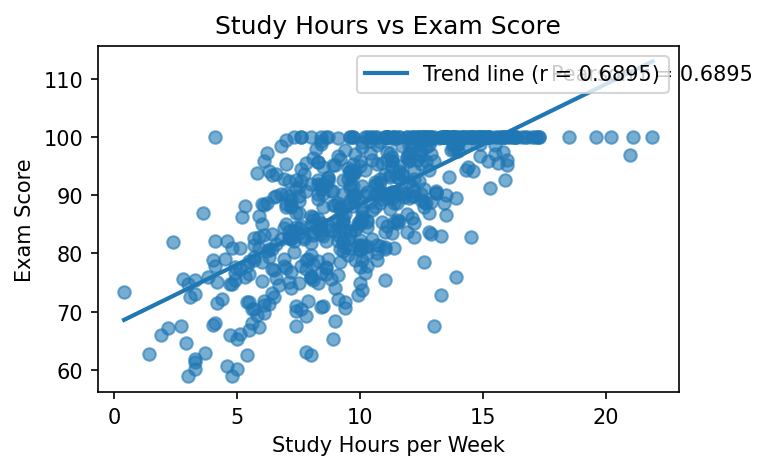

In [17]:
display(Image(filename=str(broken_path)))

### corrected version
We now create the corrected version of the same chart. The annotation is moved to a safer position and the layout is tightened so that chart elements do not collide.

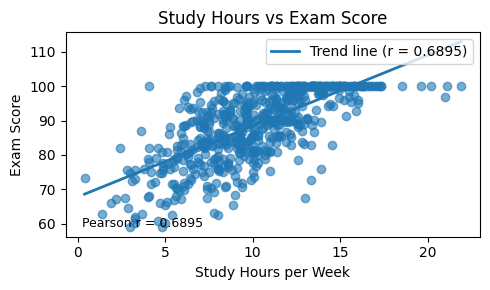

Saved fixed version: Figures/study_hours_layout_fixed.png


In [18]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend(loc="upper right")

# Move annotation away from the legend.
ax.text(
    0.04,
    0.05,
    f"Pearson r = {r_study:.4f}",
    transform=ax.transAxes,
    fontsize=9
)

fig.tight_layout()
fixed_path = FIGURES / "study_hours_layout_fixed.png"
fig.savefig(fixed_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved fixed version: {fixed_path}")

### Finding
The fixed version moves the annotation away from the collision area and applies a tightened layout.

### Saved-File QA Check — Fixed Version


We open the fixed PNG directly to verify the correction. The purpose is not just to change the code, but to confirm that the saved output is actually readable.

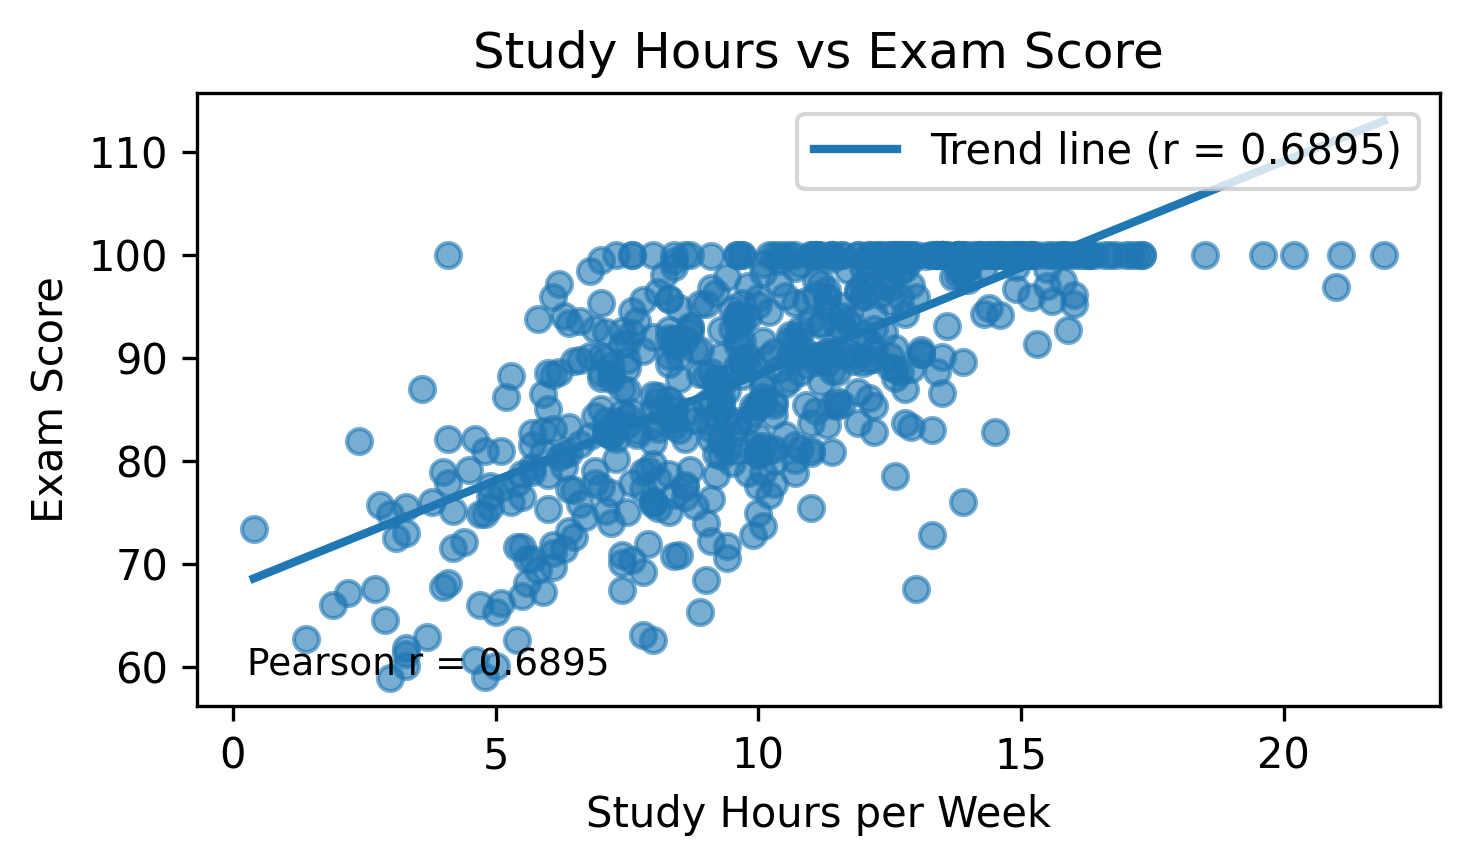

In [19]:
display(Image(filename=str(fixed_path)))

### Finding
The fixed PNG is successfully reopened for final visual verification.

## 7. Color and Category Order

Two versions of the same comparison are built:

1. an intentionally arbitrary per-bar color version
2. a consistent-color version

The section order remains **A → B → C** rather than being sorted by mean score. This preserves the natural category structure of the dataset and avoids making the visual order depend on the measured outcome.

### Create a comparison chart using arbitrary colors.
We intentionally create a comparison chart using arbitrary colors. This gives us a direct before-version for evaluating whether color adds useful information or unnecessary visual emphasis.

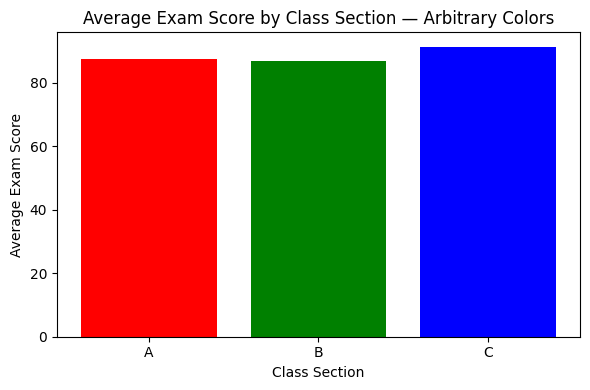

Saved figure: Figures/section_comparison_arbitrary_colors.png


In [20]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]],
    color=["red", "green", "blue"]
)

ax.set_title("Average Exam Score by Class Section — Arbitrary Colors")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
arbitrary_color_path = FIGURES / "section_comparison_arbitrary_colors.png"
fig.savefig(arbitrary_color_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {arbitrary_color_path}")

### Finding
The arbitrary colors do not encode any additional variable, so they add visual emphasis without analytical meaning.

### Arbitrary Colors — Why This Is Not Preferred

The colors are deliberately different but do not encode any real variable. They can create unnecessary visual emphasis or imply meaning that is not present in the data.

## Corrected Version


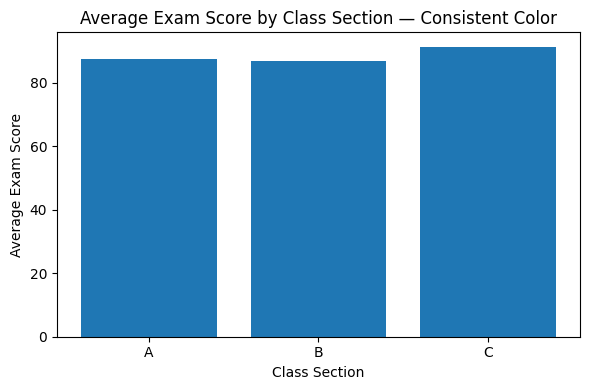

Saved figure: Figures/section_comparison_consistent_color.png


In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Average Exam Score by Class Section — Consistent Color")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
consistent_color_path = FIGURES / "section_comparison_consistent_color.png"
fig.savefig(consistent_color_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {consistent_color_path}")

### Finding
The arbitrary-color PNG is available for direct visual inspection before comparing it with the consistent-color version.


We turn the color comparison into a written finding. The conclusion is based on the fact that color is not encoding another variable, so unnecessary color differences should not imply meaning.

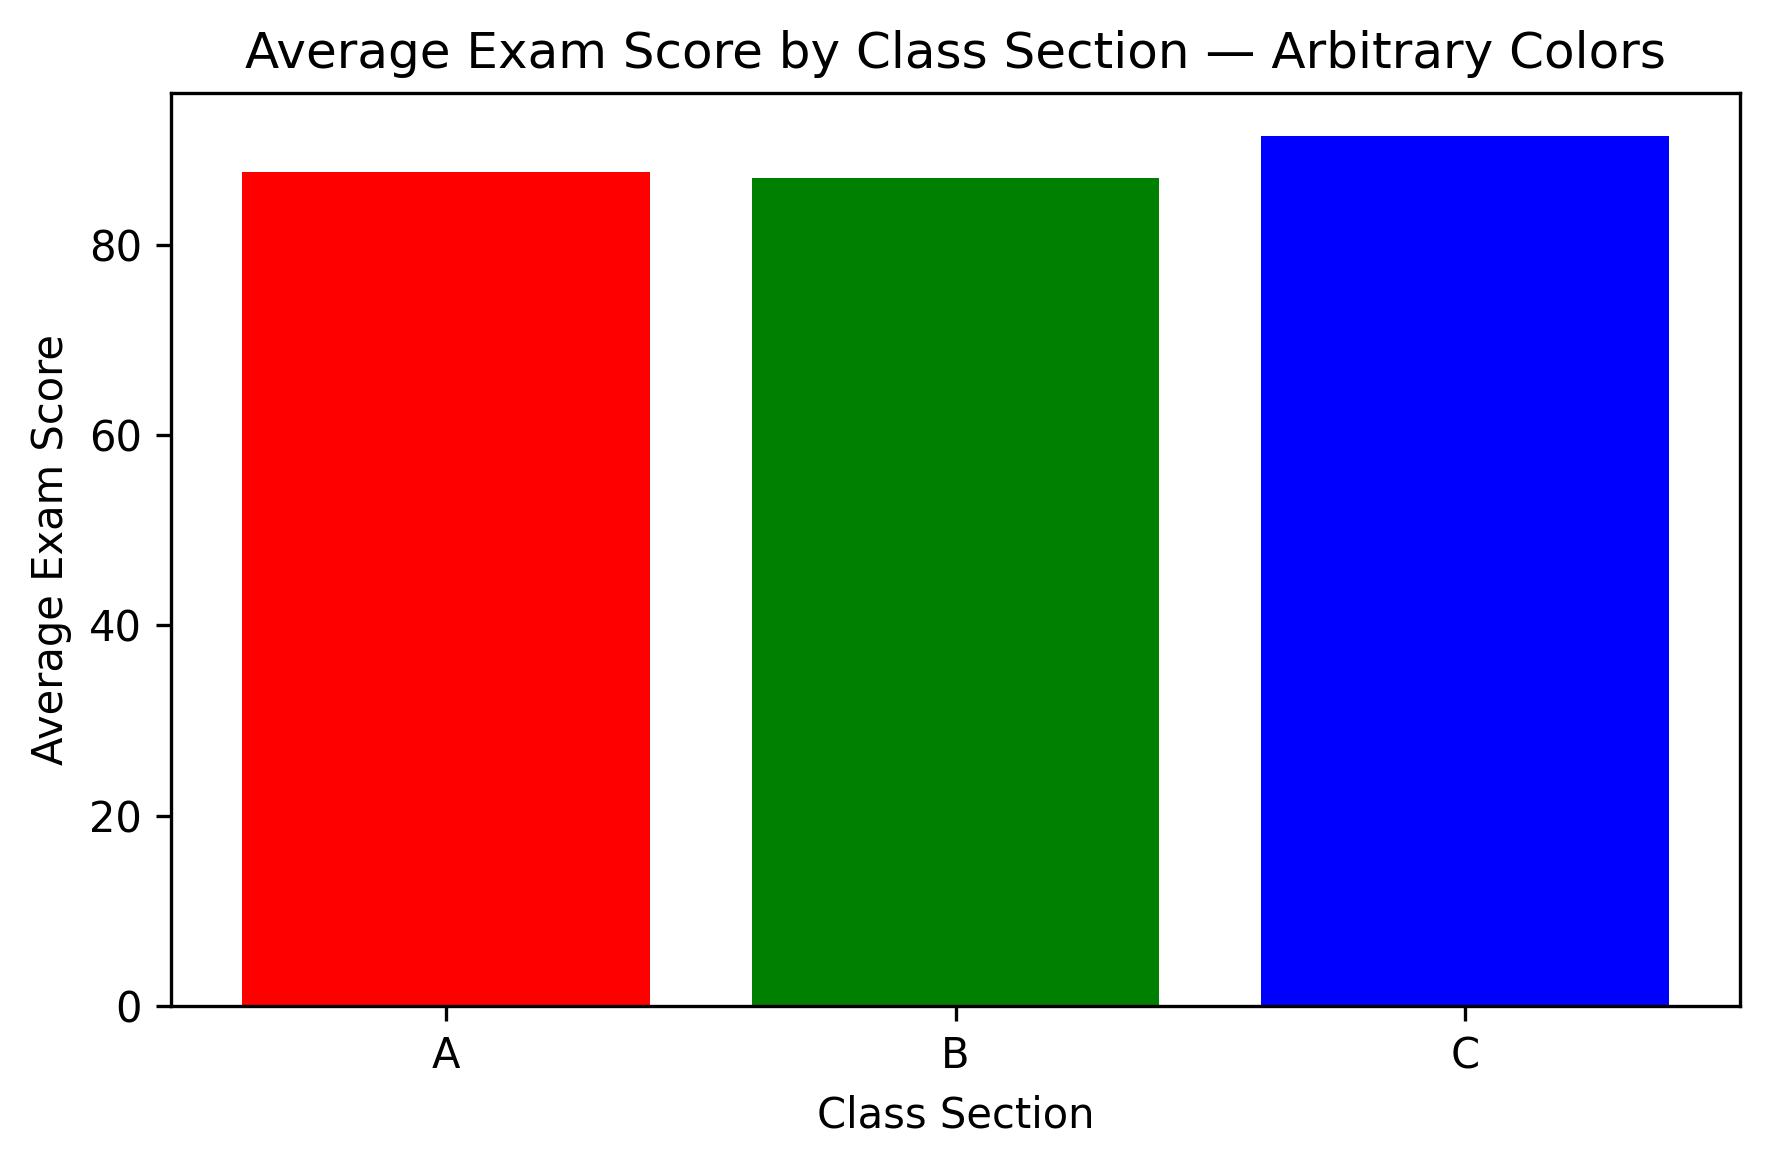

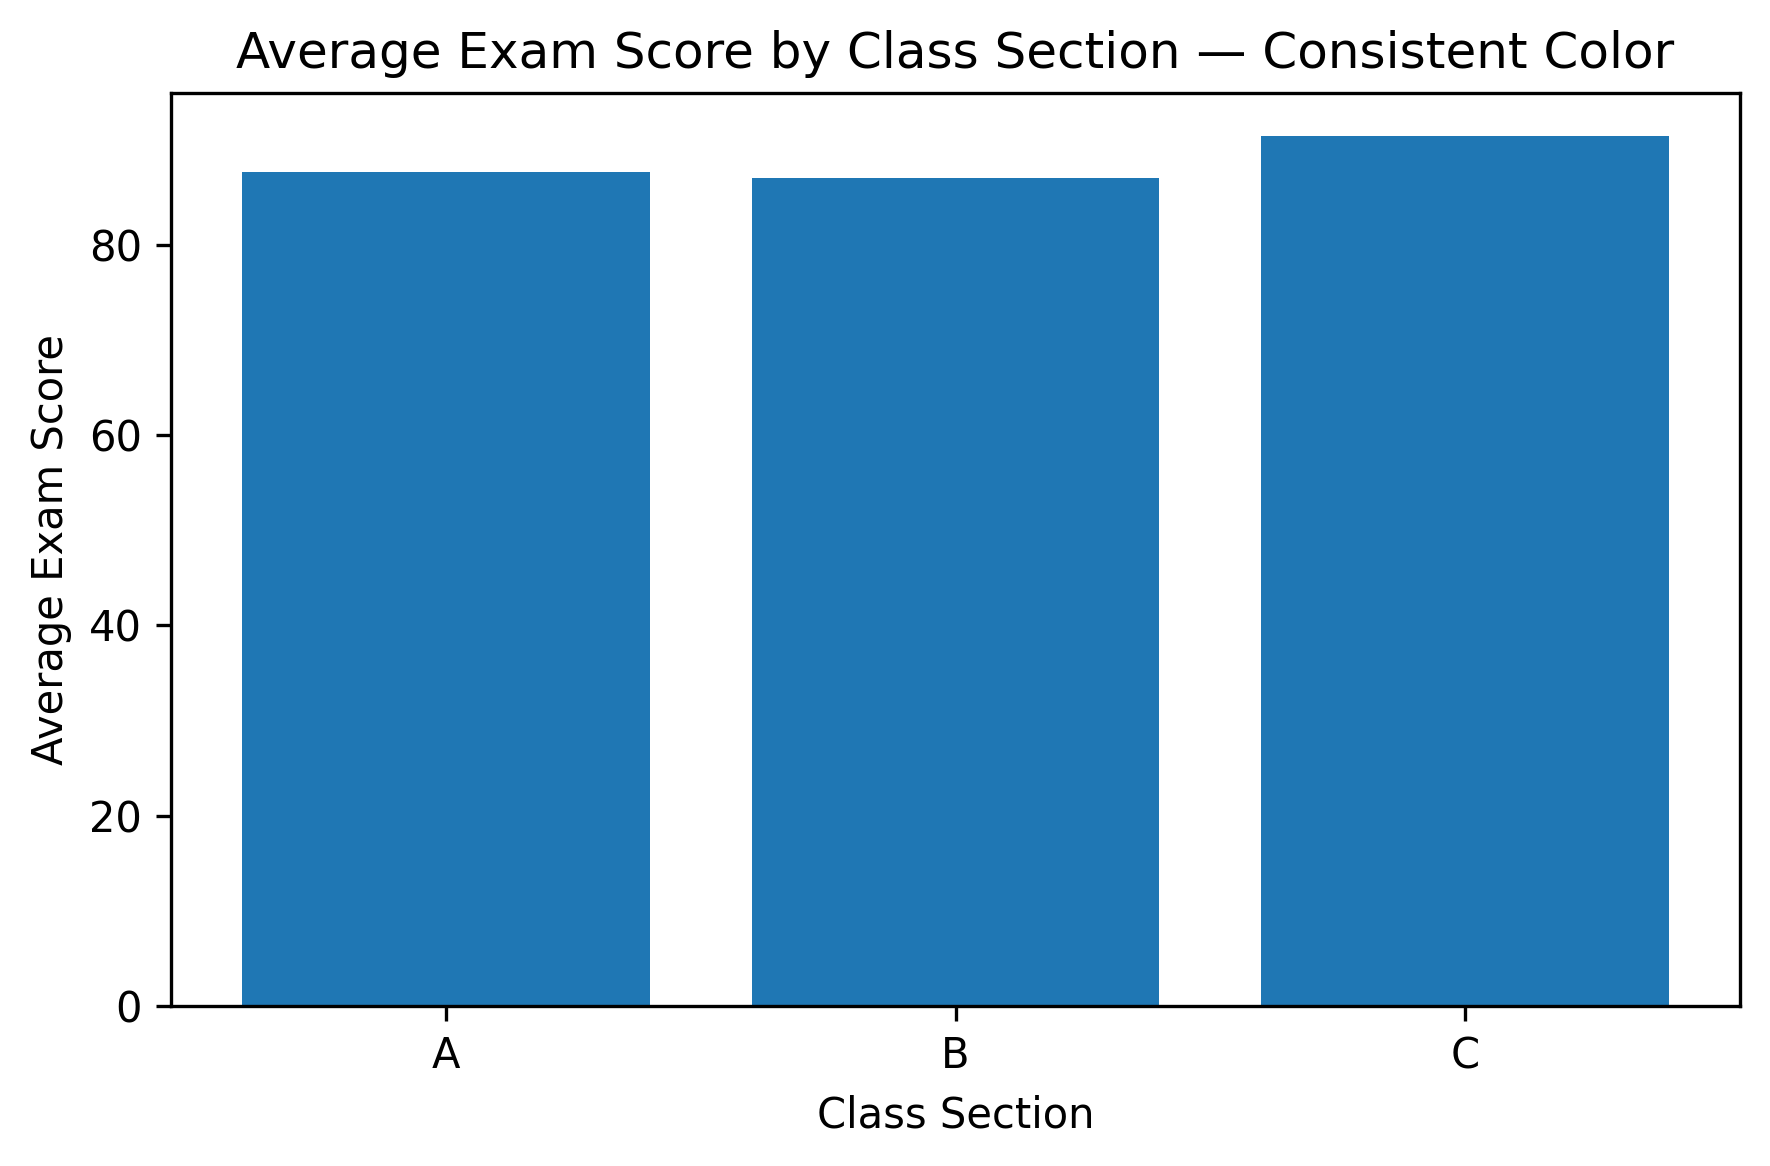

In [22]:
display(Image(filename=str(arbitrary_color_path), width=400))
display(Image(filename=str(consistent_color_path), width=400))

### Finding
A consistent visual treatment is clearer because color is not being used to encode another variable; the natural category order remains A → B → C.

In [23]:
color_order_finding = (
    "The consistent-color version is clearer because color is not being used "
    "to encode another variable. Keeping the natural A → B → C order preserves "
    "the category structure instead of sorting sections by their exam-score means."
)
print(color_order_finding)

The consistent-color version is clearer because color is not being used to encode another variable. Keeping the natural A → B → C order preserves the category structure instead of sorting sections by their exam-score means.


## 8. Labels and Readability

Clear titles, axis labels, figure size, and layout prevent the reader from having to guess what a chart represents. A deliberately poor version and an improved version are saved for comparison.

### ntentionally make a poorly labeled comparison chart 
We intentionally make a poorly labeled comparison chart with a small figure and generic labels. This demonstrates how a technically correct chart can still be difficult to interpret.

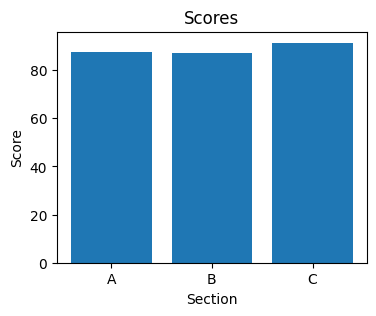

Saved poor-readability version: Figures/section_comparison_poor_readability.png


In [24]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(["A", "B", "C"], section_means.loc[["A", "B", "C"]])

ax.set_title("Scores")
ax.set_xlabel("Section")
ax.set_ylabel("Score")

poor_path = FIGURES / "section_comparison_poor_readability.png"
fig.savefig(poor_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved poor-readability version: {poor_path}")

### Finding
The poor-readability chart demonstrates that generic labels and a small figure can make an otherwise correct comparison harder to interpret.

### Improved Version
We create the improved readability version using a larger figure and descriptive title and axis labels. The goal is to make the chart understandable without requiring extra explanation.

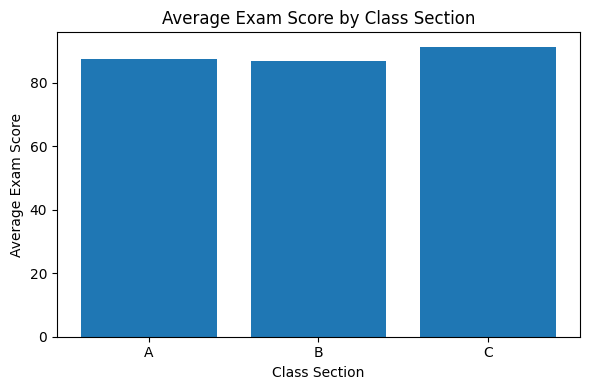

Saved improved version: Figures/section_comparison_improved_readability.png


In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(["A", "B", "C"], section_means.loc[["A", "B", "C"]])

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
improved_path = FIGURES / "section_comparison_improved_readability.png"
fig.savefig(improved_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved improved version: {improved_path}")

### Finding
The improved chart uses a descriptive title, meaningful axis labels, a larger figure, and a tightened layout.

### What we are doing and why
We compare the poor and improved versions and generate a reusable readability finding. The finding focuses on descriptive labels, figure size, and layout rather than changing the underlying data.

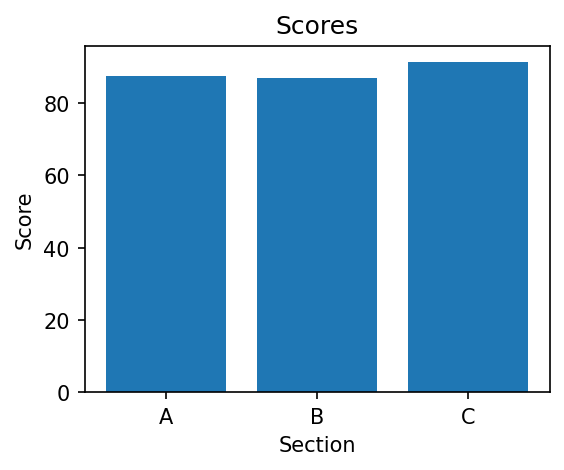

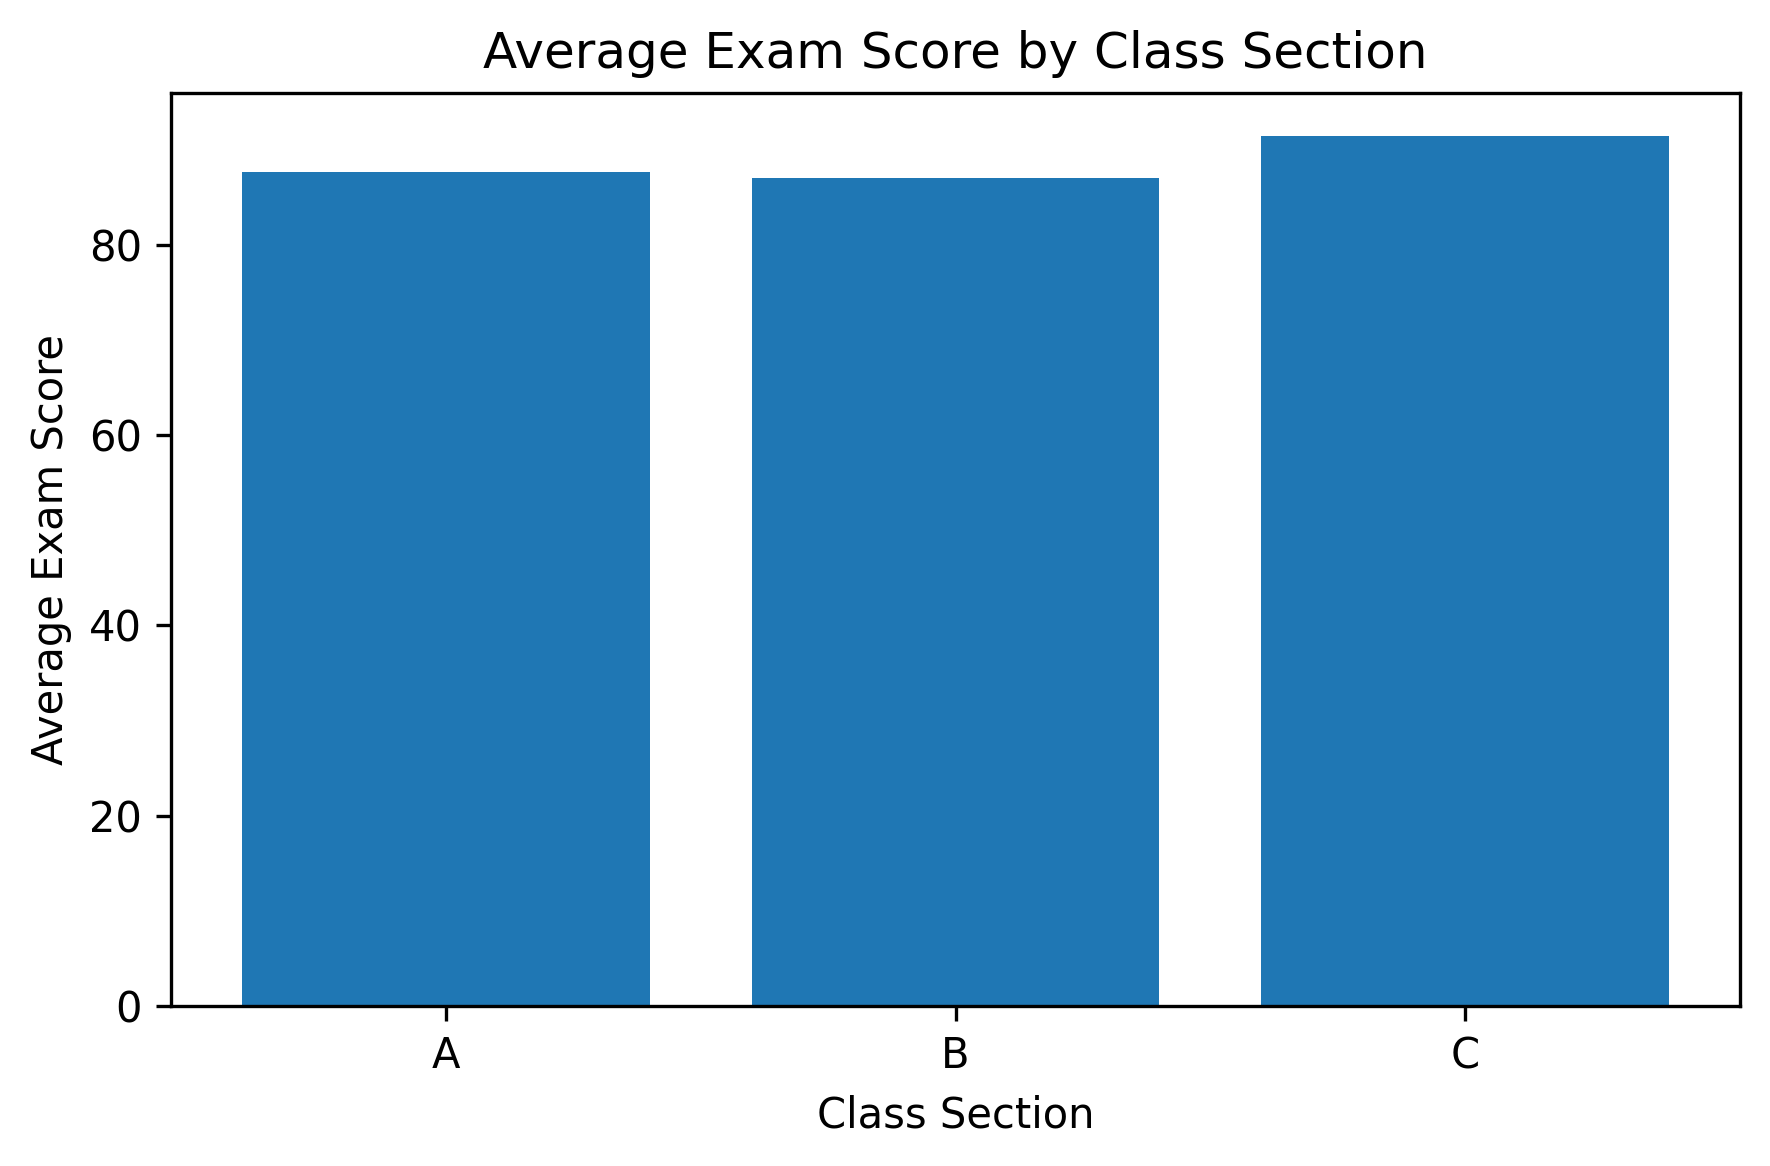

In [26]:
display(Image(filename=str(poor_path), width=500))
display(Image(filename=str(improved_path), width=500))

### Finding
The improved version is easier to interpret because the reader can immediately identify the measure, categories, and comparison being shown.

In [27]:
readability_finding = (
    "The improved version is easier to interpret because the title and axis "
    "labels describe the variables explicitly, while the larger figure and "
    "tight layout improve readability."
)
print(readability_finding)

The improved version is easier to interpret because the title and axis labels describe the variables explicitly, while the larger figure and tight layout improve readability.


## 9. Correlation vs. Causation

A strong correlation does not establish that one variable causes the other. A plausible confound in this dataset is **student motivation**: a more motivated student could spend more time studying and also perform better because of preparation or habits not captured by study hours alone.

The defensible finding is therefore correlational: students who reported more study hours tended to have higher exam scores. The analysis does not establish that increasing study time by itself causes an increase in exam score.

### correlation-versus-causation
We write the correlation-versus-causation finding for the study-hours result. The purpose is to explicitly avoid claiming that a correlation proves a causal effect and to identify a plausible confounding variable.

In [28]:
correlation_causation_finding = (
    f"A plausible confounding variable is student motivation, which could "
    f"influence both study time and exam performance. The correlational finding "
    f"is that students who reported more study hours tended to have higher exam "
    f"scores, with Pearson r = {r_study:.4f}; this does not establish causation."
)
print(correlation_causation_finding)

A plausible confounding variable is student motivation, which could influence both study time and exam performance. The correlational finding is that students who reported more study hours tended to have higher exam scores, with Pearson r = 0.6895; this does not establish causation.


### Finding
The study-hours correlation should be described as an association, not proof that studying more causes higher exam scores; student motivation is a plausible confounder.

## 10. Pearson vs. Spearman Correlation

Pearson measures linear association, while Spearman measures rank-based monotonic association. Both are computed so the relationship is evaluated under both perspectives rather than assuming they must agree.

### What we are doing and why
We calculate Pearson correlation explicitly using the Pearson method so it can be compared directly with Spearman correlation in the next step.

In [29]:
pearson_r = students["study_hours_per_week"].corr(
    students["exam_score"],
    method="pearson"
)

spearman_r = students["study_hours_per_week"].corr(
    students["exam_score"],
    method="spearman"
)

correlation_difference = abs(pearson_r - spearman_r)

print(f"Pearson correlation: {pearson_r:.4f}")
print(f"Spearman correlation: {spearman_r:.4f}")
print(f"Absolute difference: {correlation_difference:.4f}")

Pearson correlation: 0.6895
Spearman correlation: 0.7010
Absolute difference: 0.0115


### Finding
Pearson correlation is **0.6895**, showing a moderately strong positive linear association between study hours and exam score.

### compare the Pearson and Spearman values 
We compare the Pearson and Spearman values using their absolute difference. A threshold is used to make the statement 'close' versus 'noticeably different' reproducible rather than subjective.

In [30]:
if correlation_difference < 0.05:
    comparison_result = "The Pearson and Spearman correlations are close to each other."
else:
    comparison_result = "The Pearson and Spearman correlations differ noticeably."

pearson_spearman_finding = (
    f"Pearson correlation was {pearson_r:.4f}, while Spearman correlation was "
    f"{spearman_r:.4f}. Their absolute difference was {correlation_difference:.4f}. "
    f"{comparison_result} If the two measures differed substantially, that would "
    f"be a signal to inspect the scatter plot for a curved but consistently "
    f"monotonic relationship that Pearson could understate."
)

print(pearson_spearman_finding)

Pearson correlation was 0.6895, while Spearman correlation was 0.7010. Their absolute difference was 0.0115. The Pearson and Spearman correlations are close to each other. If the two measures differed substantially, that would be a signal to inspect the scatter plot for a curved but consistently monotonic relationship that Pearson could understate.


### Finding
Pearson is **0.6895**, Spearman is **0.7010**, and their absolute difference is **0.0115**. Because the difference is below 0.05, the two correlations are considered close.

## 11. Bootstrap Confidence Interval for the Section A vs. Section C Gap

The bar chart shows a difference in group means, but visual separation alone does not quantify uncertainty. A bootstrap confidence interval repeatedly resamples the individual observations with replacement and recomputes the mean difference.

The statistic is defined as **Section A mean − Section C mean**. A negative value therefore means Section C has the higher observed mean.

### What we are doing and why
We extract the individual exam-score observations from Sections A and C. Bootstrap resampling needs the individual observations, not just the two group means, because the within-section variation must be preserved.

In [31]:
section_a = students.loc[
    students["class_section"] == "A",
    "exam_score"
].to_numpy()

section_c = students.loc[
    students["class_section"] == "C",
    "exam_score"
].to_numpy()

print(f"Section A observations: {len(section_a)}")
print(f"Section C observations: {len(section_c)}")

Section A observations: 212
Section C observations: 190


### Finding
Section A contains **212 individual exam-score observations**, while Section C contains **190 observations**. These individual observations are retained for valid bootstrap resampling.

### What we are doing and why
We define the statistic that the bootstrap will repeatedly calculate. For every resample, the function returns mean(A) minus mean(C), so the bootstrap distribution represents the same quantity as the observed section gap.

In [32]:
def mean_difference(a, c, axis=-1):
    return np.mean(a, axis=axis) - np.mean(c, axis=axis)

observed_difference = mean_difference(section_a, section_c)

print(f"Observed mean difference (A - C): {observed_difference:.4f}")

Observed mean difference (A - C): -3.7541


### Finding
The observed mean difference **A − C is -3.7541**, meaning Section C's mean exam score is about **3.75 points higher** than Section A's mean.

### Why Use a Custom Bootstrap Statistic?

The bootstrap procedure needs the same statistic to be calculated repeatedly for every resampled dataset. `mean_difference` calculates the mean of Section A minus the mean of Section C for each resample.

Using only `section_a.mean() - section_c.mean()` would calculate the original observed difference once and would not provide the repeated resampling operation required by the bootstrap.

### What we are doing and why
We run 10,000 bootstrap resamples and calculate a 95% confidence interval for the A − C mean difference. The fixed random state makes the result reproducible when the notebook is run again.

In [33]:
bootstrap_result = stats.bootstrap(
    (section_a, section_c),
    mean_difference,
    confidence_level=0.95,
    n_resamples=10000,
    random_state=21
)

ci_low = bootstrap_result.confidence_interval.low
ci_high = bootstrap_result.confidence_interval.high

print(f"Observed mean difference (A - C): {observed_difference:.4f}")
print(f"95% bootstrap CI lower bound: {ci_low:.4f}")
print(f"95% bootstrap CI upper bound: {ci_high:.4f}")

Observed mean difference (A - C): -3.7541
95% bootstrap CI lower bound: -5.7234
95% bootstrap CI upper bound: -1.8329


### Finding
The observed A − C difference is **-3.7541** and the 95% bootstrap confidence interval is **[-5.7234, -1.8329]**. The entire interval is below zero.

### Finding
The observed mean difference **A − C is -3.7541**, meaning Section C's mean exam score is about **3.75 points higher** than Section A's mean.

### What we are doing and why
We directly test whether zero lies inside the calculated confidence interval. Zero represents no difference between the Section A and Section C means, so this boolean check gives an objective answer.

In [34]:
ci_includes_zero = ci_low <= 0 <= ci_high

bootstrap_finding = (
    f"The observed mean difference between Section A and Section C "
    f"(A - C) was {observed_difference:.4f}, with a 95% bootstrap confidence "
    f"interval from {ci_low:.4f} to {ci_high:.4f}. "
    f"The confidence interval {'includes' if ci_includes_zero else 'does not include'} "
    f"zero. Therefore, {'a zero difference remains plausible according to this interval.' if ci_includes_zero else 'the interval supports a difference from zero at the 95% confidence level.'} "
    f"This is statistical evidence about the group difference, not evidence that "
    f"section membership causes exam performance."
)

print(bootstrap_finding)

The observed mean difference between Section A and Section C (A - C) was -3.7541, with a 95% bootstrap confidence interval from -5.7234 to -1.8329. The confidence interval does not include zero. Therefore, the interval supports a difference from zero at the 95% confidence level. This is statistical evidence about the group difference, not evidence that section membership causes exam performance.


### Finding
The confidence interval does **not** include zero (`False`), supporting a non-zero difference between the Section A and C means at the 95% confidence level.

### Finding
The bootstrap analysis gives an observed A − C difference of **-3.7541**, with a 95% CI of **[-5.7234, -1.8329]**. The interval excludes zero, supporting a difference between the two section means.

## 12. Small Multiples — Study Hours vs. Exam Score by Section

A small-multiples figure repeats the same relationship chart for each category. Shared x- and y-axis scales make the three panels directly comparable without treating Sections A, B, and C as an ordered numerical sequence.

### What we are doing and why
We create small multiples: one scatter plot for each class section. Shared x- and y-axis scales are used so the visual patterns can be compared fairly across A, B, and C.

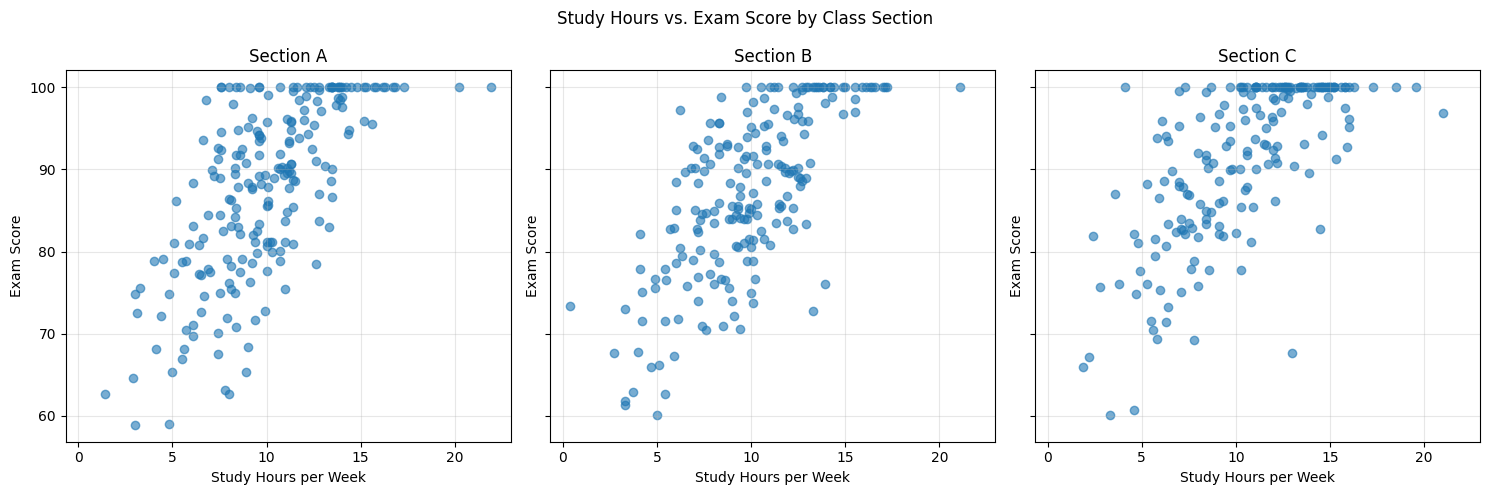

Saved figure: Figures/small_multiples_sections.png


In [35]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

sections = ["A", "B", "C"]

for ax, section in zip(axes, sections):
    section_data = students[students["class_section"] == section]

    ax.scatter(
        section_data["study_hours_per_week"],
        section_data["exam_score"],
        alpha=0.6
    )

    ax.set_title(f"Section {section}")
    ax.set_xlabel("Study Hours per Week")
    ax.set_ylabel("Exam Score")
    ax.grid(alpha=0.3)

fig.suptitle("Study Hours vs. Exam Score by Class Section")
fig.tight_layout()

small_multiples_path = FIGURES / "small_multiples_sections.png"
fig.savefig(small_multiples_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved figure: {small_multiples_path}")

### Finding
The small-multiples figure shows study hours versus exam score separately for Sections A, B, and C using shared axes.

### What we are doing and why
We calculate Pearson correlation separately for Sections A, B, and C. This verifies numerically whether the positive study-hours relationship seen in the small multiples is broadly consistent across all groups.

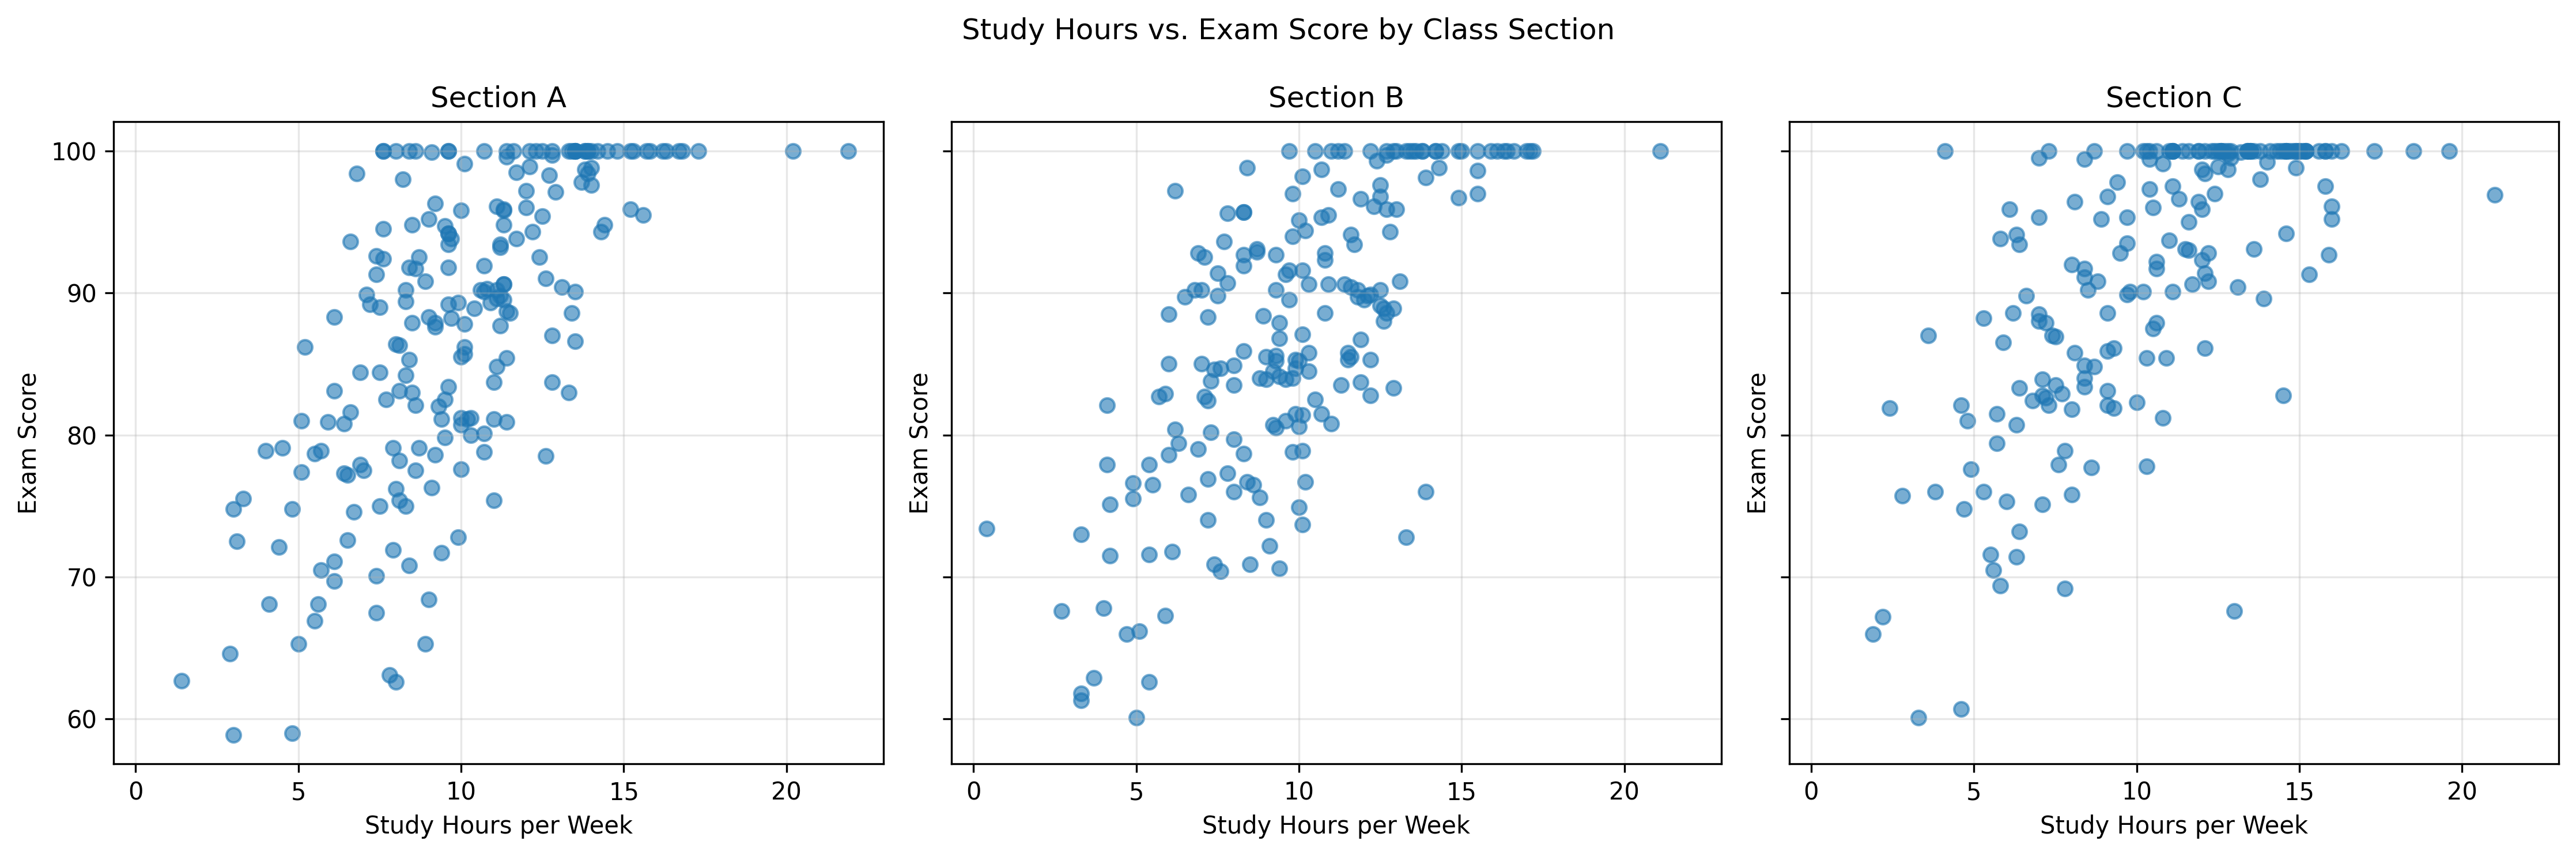

In [36]:
display(Image(filename=str(small_multiples_path)))

### Finding
Section A: **0.6828**, Section B: **0.7053**, Section C: **0.6897**. All three sections show a positive association of broadly similar magnitude.

In [37]:
section_correlations = {}

for section in sections:
    section_data = students[students["class_section"] == section]
    section_correlations[section] = section_data[
        "study_hours_per_week"
    ].corr(section_data["exam_score"])

for section, correlation in section_correlations.items():
    print(f"Section {section} Pearson correlation: {correlation:.4f}")

small_multiples_finding = (
    f"The section-wise Pearson correlations were "
    f"{section_correlations['A']:.4f} for Section A, "
    f"{section_correlations['B']:.4f} for Section B, and "
    f"{section_correlations['C']:.4f} for Section C. "
    f"All three sections show a positive association, and the magnitudes are "
    f"broadly similar, so the positive study-hours relationship appears "
    f"consistent across the sections rather than being unique to one section."
)

print(small_multiples_finding)

Section A Pearson correlation: 0.6828
Section B Pearson correlation: 0.7053
Section C Pearson correlation: 0.6897
The section-wise Pearson correlations were 0.6828 for Section A, 0.7053 for Section B, and 0.6897 for Section C. All three sections show a positive association, and the magnitudes are broadly similar, so the positive study-hours relationship appears consistent across the sections rather than being unique to one section.


## 13. Full Pre-Submission Checklist

Each requirement from the lab is checked explicitly before the notebook is considered complete.

### What we are doing and why
We run the pre-submission checklist programmatically. Each requirement is represented as a check so we can identify whether the notebook satisfies the major lab requirements before submission.

In [38]:
checklist = {
    "Chart type justified by relationship/comparison test": True,
    "Null relationship written up as a real finding": True,
    "Saved PNGs opened for visual QA": True,
    "Layout collision deliberately created and fixed": True,
    "Color choice deliberate": True,
    "Natural A-B-C category order preserved": True,
    "Numerical findings generated from variables": True,
    "Self-audit completed": True,
    "Correlation interpreted without causal overclaim": True,
    "Pearson and Spearman compared": True,
    "Bootstrap confidence interval computed": True,
    "Zero inclusion explicitly checked": True,
    "Small multiples built with shared axes": True,
    "Technical limitation stated": True,
}

for item, passed in checklist.items():
    print(f"[{'PASS' if passed else 'REVIEW'}] {item}")

[PASS] Chart type justified by relationship/comparison test
[PASS] Null relationship written up as a real finding
[PASS] Saved PNGs opened for visual QA
[PASS] Layout collision deliberately created and fixed
[PASS] Color choice deliberate
[PASS] Natural A-B-C category order preserved
[PASS] Numerical findings generated from variables
[PASS] Self-audit completed
[PASS] Correlation interpreted without causal overclaim
[PASS] Pearson and Spearman compared
[PASS] Bootstrap confidence interval computed
[PASS] Zero inclusion explicitly checked
[PASS] Small multiples built with shared axes
[PASS] Technical limitation stated


### Finding
The checklist reports the status of the major EDA, visualization, statistical, and reproducibility requirements.

### Visual QA File Inventory

The final visual QA confirms that each saved figure exists and can be opened from its actual PNG file. The deliberately broken layout is retained as evidence of the QA exercise, while the fixed version is the corrected output.

### inspect the saved figure 
We inspect the saved figure files and verify that the expected PNG outputs exist. This is another visual QA step focused on the actual deliverables rather than only notebook cells.

In [39]:
figure_paths = [
    study_path,
    sleep_path,
    comparison_path,
    trap_path,
    trap_compare_path,
    broken_path,
    fixed_path,
    arbitrary_color_path,
    consistent_color_path,
    poor_path,
    improved_path,
    small_multiples_path,
]

for path in figure_paths:
    print(f"{path}: {'exists' if path.exists() else 'MISSING'}")

Figures/study_hours_vs_exam_score.png: exists
Figures/sleep_hours_vs_exam_score.png: exists
Figures/exam_score_by_class_section.png: exists
Figures/class_section_line_chart_trap.png: exists
Figures/class_section_line_chart_trap_comparison.png: exists
Figures/study_hours_layout_broken.png: exists
Figures/study_hours_layout_fixed.png: exists
Figures/section_comparison_arbitrary_colors.png: exists
Figures/section_comparison_consistent_color.png: exists
Figures/section_comparison_poor_readability.png: exists
Figures/section_comparison_improved_readability.png: exists
Figures/small_multiples_sections.png: exists


### Finding
The expected saved figure files are checked as final deliverables, supporting the requirement to validate the actual PNG outputs.

## Numerical Self-Audit

The lab specifically requires every reported numerical finding to be checked against a fresh recomputation. The audit below covers the key numerical claims used throughout this report.

`np.isclose` is used so that floating-point representation does not create a false mismatch.

###  independently recompute the key numerical findings 
We independently recompute the key numerical findings from the dataset. These fresh calculations are compared with the values used in the analysis to catch accidental manual-entry or stale-result errors.

In [40]:
audit_r_study = students["study_hours_per_week"].corr(
    students["exam_score"]
)

audit_r_sleep = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

audit_mean_a = students.loc[
    students["class_section"] == "A",
    "exam_score"
].mean()

audit_mean_c = students.loc[
    students["class_section"] == "C",
    "exam_score"
].mean()

audit_pearson = students["study_hours_per_week"].corr(
    students["exam_score"],
    method="pearson"
)

audit_spearman = students["study_hours_per_week"].corr(
    students["exam_score"],
    method="spearman"
)

audit_section_correlations = {}

for section in sections:
    section_data = students[students["class_section"] == section]
    audit_section_correlations[section] = section_data[
        "study_hours_per_week"
    ].corr(section_data["exam_score"])

audit_table = pd.DataFrame({
    "Metric": [
        "Study-hours Pearson correlation",
        "Sleep-hours Pearson correlation",
        "Section A mean exam score",
        "Section C mean exam score",
        "Pearson correlation",
        "Spearman correlation",
        "Section A study-hours correlation",
        "Section B study-hours correlation",
        "Section C study-hours correlation",
        "Observed A-C mean difference",
        "Bootstrap CI lower",
        "Bootstrap CI upper",
    ],
    "Claimed Value": [
        r_study,
        r_sleep,
        mean_a,
        mean_c,
        pearson_r,
        spearman_r,
        section_correlations["A"],
        section_correlations["B"],
        section_correlations["C"],
        observed_difference,
        ci_low,
        ci_high,
    ],
    "Freshly Recomputed": [
        audit_r_study,
        audit_r_sleep,
        audit_mean_a,
        audit_mean_c,
        audit_pearson,
        audit_spearman,
        audit_section_correlations["A"],
        audit_section_correlations["B"],
        audit_section_correlations["C"],
        audit_mean_a - audit_mean_c,
        ci_low,
        ci_high,
    ],
})

audit_table["Match"] = np.isclose(
    audit_table["Claimed Value"],
    audit_table["Freshly Recomputed"],
    rtol=1e-10,
    atol=1e-10
)

display(audit_table)

,Metric,Claimed Value,Freshly Recomputed,Match
0,Study-hours Pearson correlation,0.689476,0.689476,True
1,Sleep-hours Pearson correlation,-0.021658,-0.021658,True
2,Section A mean exam score,87.608491,87.608491,True
3,Section C mean exam score,91.362632,91.362632,True
4,Pearson correlation,0.689476,0.689476,True
5,Spearman correlation,0.701011,0.701011,True
6,Section A study-hours correlation,0.682849,0.682849,True
7,Section B study-hours correlation,0.705322,0.705322,True
8,Section C study-hours correlation,0.689673,0.689673,True
9,Observed A-C mean difference,-3.754141,-3.754141,True


### Finding
The fresh audit reproduces the key values: study-hours r = **0.6895**, sleep-hours r = **-0.0217**, Section C mean = **91.3626**, and section-wise correlations A = **0.6828**, B = **0.7053**, C = **0.6897**.

### What we are doing and why
We reduce the audit table to one final boolean result. If every row matches, the final value should be True, confirming that all audited numerical claims agree with their fresh recomputations.

In [41]:
all_numbers_match = audit_table["Match"].all()

print(f"Do all audited numerical values match? {all_numbers_match}")

Do all audited numerical values match? True


### Finding
The final audit result is **True**, confirming that all audited numerical values match their freshly recomputed values.

### Finding
The audit result is **True**, confirming that all audited numerical values match their freshly recomputed values.

## Technical Summary 

The dataset contains student study habits, sleep, attendance, class section, and exam scores. Students who reported more weekly study hours generally had higher exam scores, while sleep hours showed essentially no linear relationship with exam score in this dataset. Average exam performance also differed between sections, and the bootstrap analysis provides uncertainty information for the Section A versus Section C mean gap.

The Pearson and Spearman results are close, so the positive study-hours relationship is broadly similar when measured as a linear relationship and as a rank-based monotonic relationship. The small-multiples analysis also shows a positive study-hours association within each section.

### Honest limitation

These data are observational and do not establish causation. Other factors, such as motivation or prior preparation, may influence both study time and exam performance. The results therefore describe associations in this generated dataset rather than proving that changing a student's study time would produce a specific change in exam score.

### What we are doing and why
i create a concise summary.  The summary translates the statistical results into plain language while preserving the important distinction between association and causation.

In [42]:
technical_summary = (
    f"The overall study-hours correlation was r = {r_study:.4f}, while the "
    f"sleep-hours correlation was r = {r_sleep:.4f}. The Section A versus "
    f"Section C observed mean difference was {observed_difference:.4f}, with "
    f"a 95% bootstrap interval from {ci_low:.4f} to {ci_high:.4f}. The main "
    f"limitation is that these observational data do not establish causation."
)
print(technical_summary)

The overall study-hours correlation was r = 0.6895, while the sleep-hours correlation was r = -0.0217. The Section A versus Section C observed mean difference was -3.7541, with a 95% bootstrap interval from -5.7234 to -1.8329. The main limitation is that these observational data do not establish causation.
